In [9]:
"""
Solar Lulls - 2026 Grad Colloquium Duration Risk
====================================
Description: This notebook will open swt data and assess when solar dorught is occuring in Australia and their associated risk.

Version History: 18/06/2026, written by Olivia Hugh-Jones

Notes:

"""

'\nSolar Lulls - 2026 Grad Colloquium Duration Risk\n====================================\nDescription: This notebook will open swt data and assess when solar dorught is occuring in Australia and their associated risk.\n\nVersion History: 18/06/2026, written by Olivia Hugh-Jones\n\nNotes:\n\n'

In [11]:
from pathlib import Path
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [12]:
risk = pd.read_csv("/scratch/nf33/oj9185/GC_26_Solar_lull/HACKATHON/event_risk_by_duration_all_days.csv")

In [21]:
regions = risk.columns.drop('time')

medium_days = {}

for region in regions: 
    medium_days[region]= np.count_nonzero(risk[region] == 'medium')

medium_days = pd.DataFrame({
    'region': medium_days.keys(),
    'medium_days': medium_days.values()
})

medium_days = medium_days[medium_days['region'] != 'Unnamed: 0']
medium_days

#medium_days = pd.Series(medium_days)
#print(medium_days.sort_values(ascending=False))

,region,medium_days
1,Q5,135
2,T2,581
3,Q8,233
4,V5,386
5,V1,390
6,T3,300
7,S6,120
8,V2,197
9,Q9,198
10,Q7,216


In [14]:
gdf = gpd.read_file('/scratch/nf33/ad1803/GC26_Solar_Lull/Training/Data/REZs/REZ_Map.shp')
gdf

,name,source_fil,geometry
0,Q1,shapefile_1,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -..."
1,Q2,shapefile_1,"POLYGON Z ((143.72015 -16.97938 0, 143.87955 -..."
2,Q3,shapefile_1,"POLYGON Z ((146.27782 -18.7192 0, 146.28263 -1..."
3,Q4,shapefile_1,"POLYGON Z ((147.64366 -19.94015 0, 147.68341 -..."
4,Q5,shapefile_1,"POLYGON Z ((145.82086 -23.84279 0, 145.7004 -2..."
5,Q6,shapefile_1,"POLYGON Z ((149.9586 -24.15382 0, 149.93313 -2..."
6,Q7,shapefile_1,"POLYGON Z ((152.2709 -25.06574 0, 152.277 -25...."
7,Q8,shapefile_1,"POLYGON Z ((150.85196 -26.29194 0, 151.08218 -..."
8,Q9,shapefile_1,"POLYGON Z ((149.13813 -23.31492 0, 149.33179 -..."
9,N1,shapefile_1,"POLYGON Z ((149.63862 -28.78058 0, 149.71236 -..."


In [40]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

In [41]:
rez_medium = gdf.merge(medium_days, left_on='name', right_on='region', how='left')

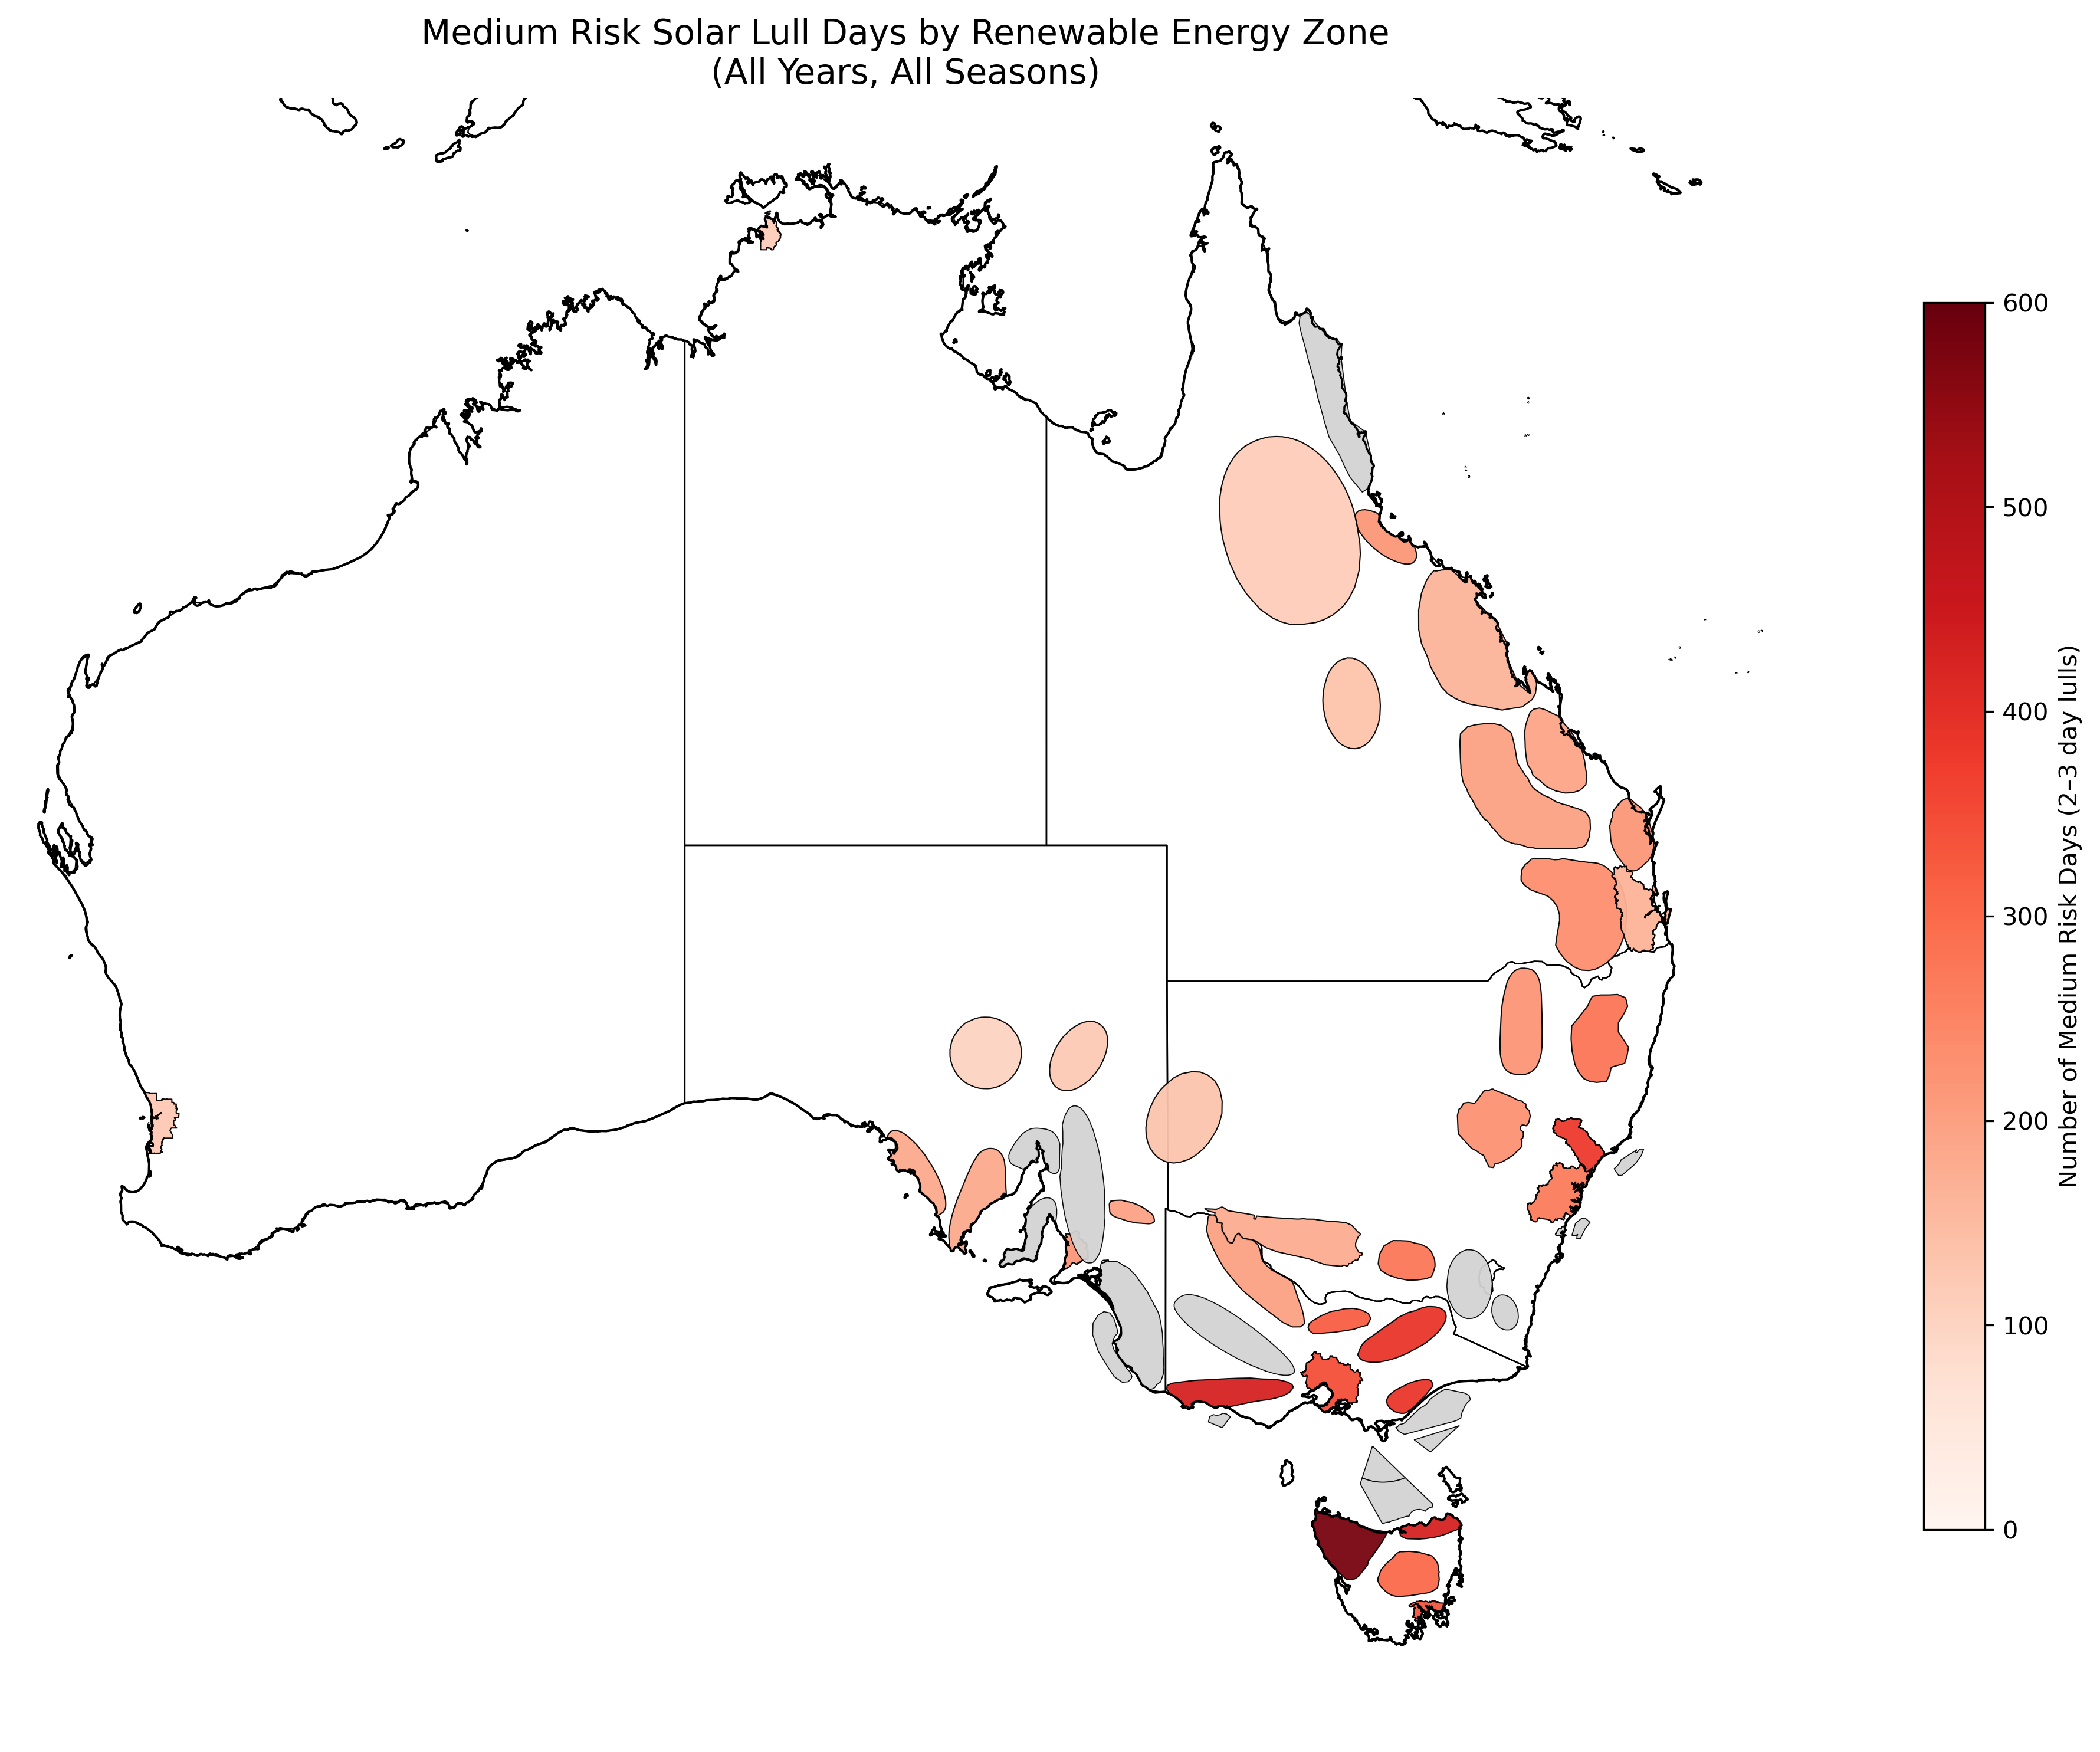

In [43]:
# Convert to latitude/longitude for Cartopy coastlines
gdf_plot = gdf_medium.to_crs(epsg=4326)

fig = plt.figure(figsize=(15, 10), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

norm = mcolors.Normalize(vmin=0, vmax=600)

# Plot renewable energy zones
gdf_plot.plot(
    column='medium_days',
    ax=ax,
    cmap='Reds',
    norm=norm,
    legend=True,
    edgecolor='black',           # sharper region boundaries
    linewidth=0.5,
    alpha=0.95,
    zorder=2,
    legend_kwds={
        'label': 'Number of Medium Risk Days (2–3 day lulls)',
        'shrink': 0.75
    },
    missing_kwds={
        'color': 'lightgrey',
        'edgecolor': 'black',
        'linewidth': 0.4,
        'label': 'No data'
    }
)

# Add coastlines
ax.coastlines(
    resolution='10m',
    color='black',
    linewidth=0.8,
    zorder=3
)

# Optional: add Australian state/country boundary context
ax.coastlines(resolution="10m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.6)

# Zoom to the extent of your shapefile
minx, miny, maxx, maxy = gdf_plot.total_bounds
pad_x = (maxx - minx) * 0.08
pad_y = (maxy - miny) * 0.08

ax.set_extent(
    [minx - pad_x, maxx + pad_x, miny - pad_y, maxy + pad_y],
    crs=ccrs.PlateCarree()
)

ax.set_title(
    'Medium Risk Solar Lull Days by Renewable Energy Zone\n(All Years, All Seasons)',
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()


In [45]:
def viv_funk(x,y):
    result = x+y
    return result

In [53]:
def plot_risk_map(risk, gdf, risk_level):
    
    # Count days for this risk level per region
    regions = [r for r in risk.columns if r not in ['time', 'Unnamed: 0']]
    day_counts = pd.DataFrame({
        'region': regions,
        'days':   [np.count_nonzero(risk[r] == risk_level) for r in regions]
    })
    norm = mcolors.Normalize(vmin=0, vmax=600)
    # Merge with shapefile
    gdf_plot = gdf.merge(day_counts, left_on='name', right_on='region', how='left')

    # Plot
    fig = plt.figure(figsize=(10, 10))
    ax  = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([110, 155, -45, -10], crs=ccrs.PlateCarree())

    gdf_plot.plot(column='days', cmap='Reds', linewidth=0.5, edgecolor='black',
                  legend=False, ax=ax, transform=ccrs.PlateCarree(),
                  missing_kwds={'color': 'lightgrey', 'edgecolor': 'black'})

    ax.coastlines(resolution='10m', linewidth=1.0)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.add_feature(cfeature.STATES, linewidth=0.6)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels  = False
    gl.right_labels = False
    gl.xlines = False
    gl.ylines = False

    sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=0, vmax=gdf_plot['days'].max()))
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.05)
    cbar.set_label('Number of Solar Lull Days')

    ax.set_title(f'{risk_level.capitalize()} Risk Solar Lull Days by Region')
    plt.tight_layout()
    plt.show()

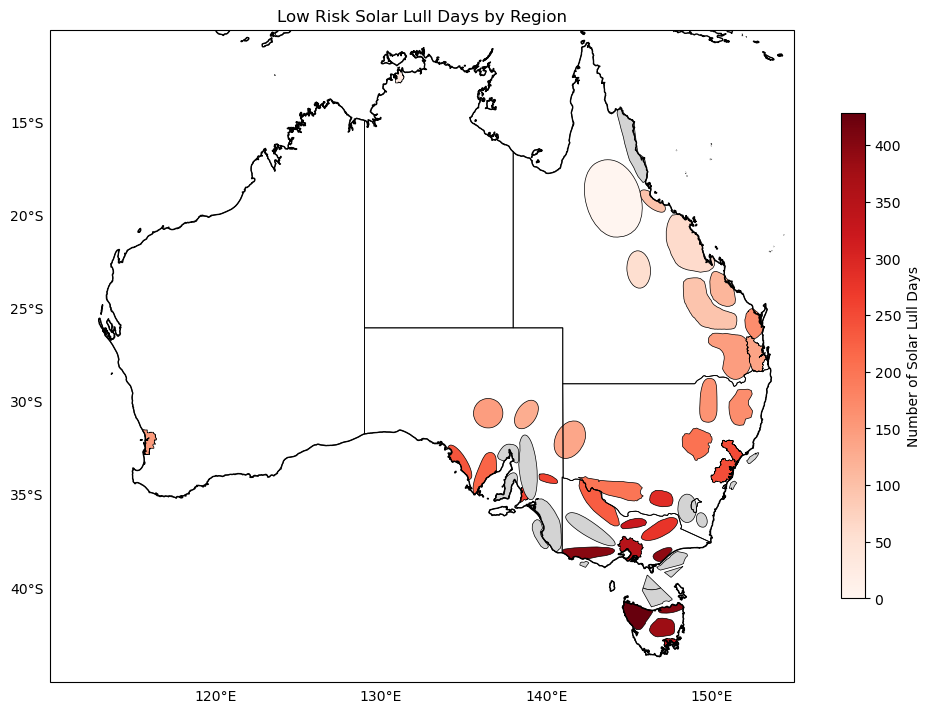

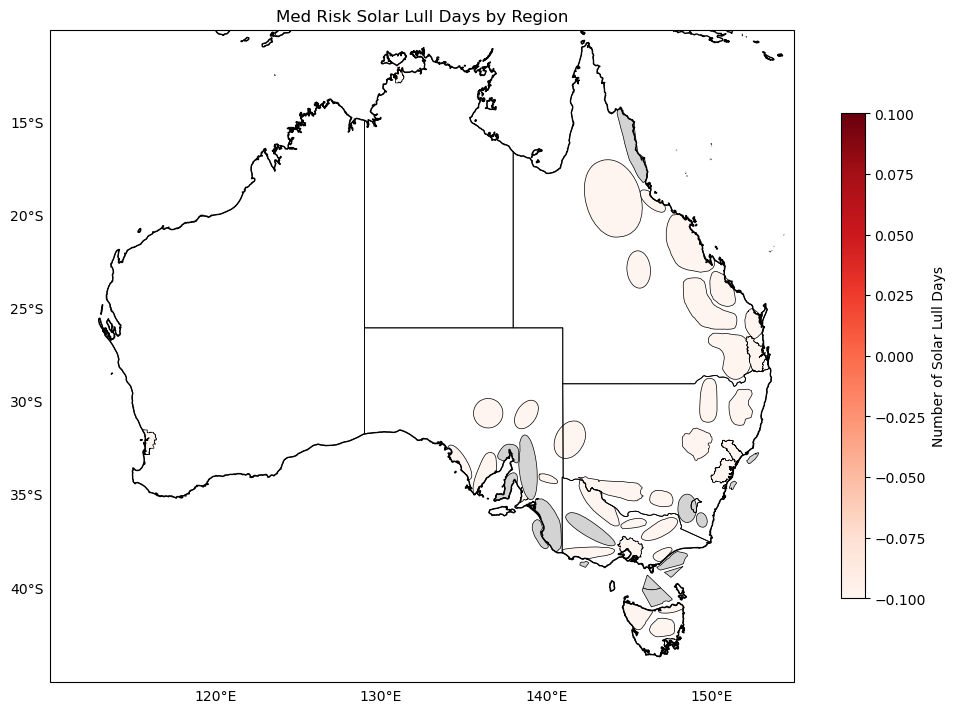

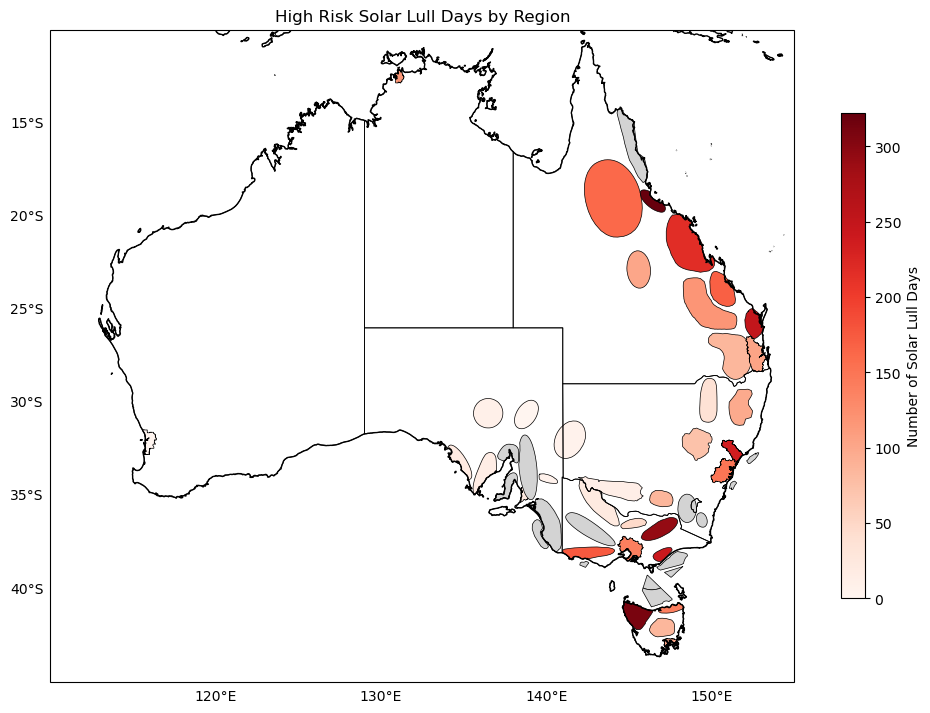

In [54]:
plot_risk_map(risk, gdf, 'low')
plot_risk_map(risk, gdf, 'med')
plot_risk_map(risk, gdf, 'high')